In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import SVG, display
import matplotlib as mpl
import json

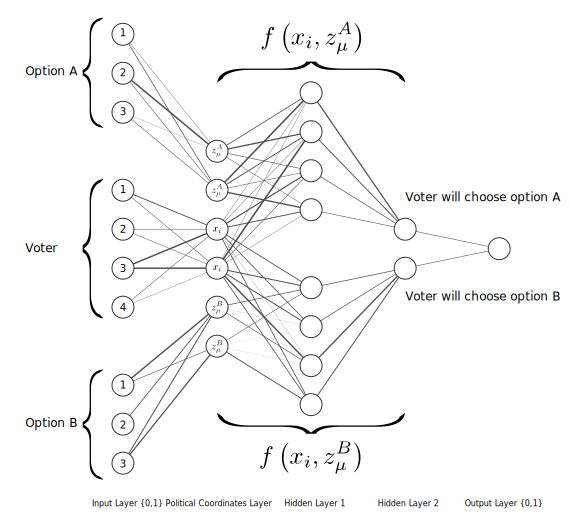

In [44]:
 Path to your SVG file
svg_file1 = "Output/NOMINATENN A Figure.svg"

# Display the SVG
display(SVG(svg_file1))

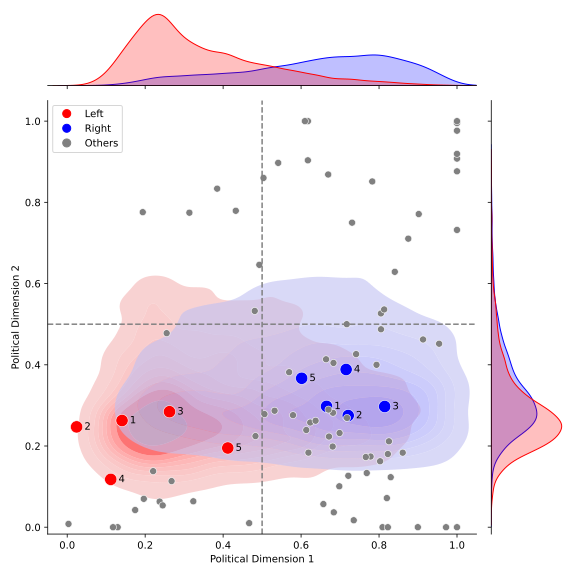

In [47]:
#Path to your SVG file
svg_file2 = "Output/paper_fig_2c.svg"

# Display the SVG
display(SVG(svg_file2))

C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


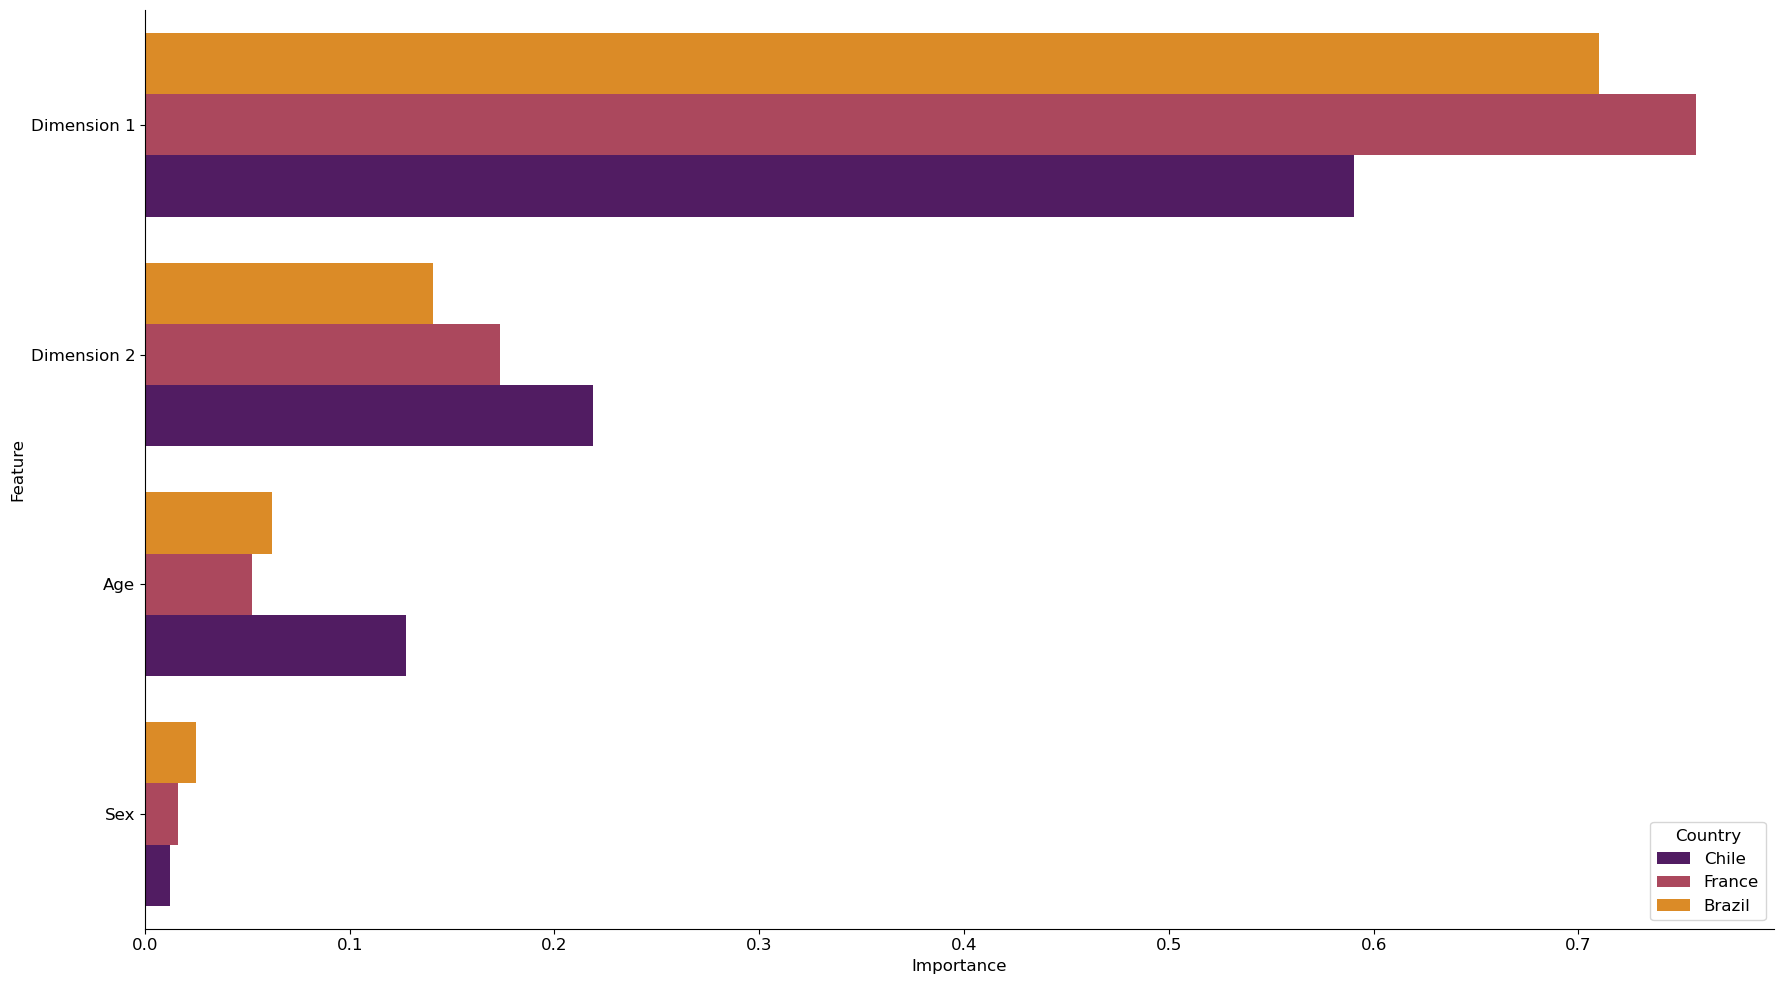

In [53]:
# Read and prepare the data

# --- Standardize fonts ---
mpl.rcParams['font.size']       = 12
mpl.rcParams['axes.labelsize']  = 14
mpl.rcParams['axes.titlesize']  = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12

data_combined_cleaned = pd.read_csv('Data/Cleaned_Feature_Importance_Data.csv')

# Set the desired order for features and countries
data_combined_cleaned['Feature'] = pd.Categorical(
    data_combined_cleaned['Feature'],
    categories=['Sex', 'Age', 'Dimension 2', 'Dimension 1'],
    ordered=True
)
data_combined_cleaned['Country'] = pd.Categorical(
    data_combined_cleaned['Country'],
    categories=['Chile', 'France', 'Brazil'],
    ordered=True
)

data_combined_cleaned = data_combined_cleaned.sort_values(by=['Feature', 'Country'])

fig, ax = plt.subplots(1, 1, figsize=(18, 10))
sns.barplot(
    data=data_combined_cleaned,
    y='Feature', x='Importance',
    hue='Country',
    hue_order=['Chile', 'France', 'Brazil'],
    palette='inferno',
    ax=ax
)

ax.set_xlabel('Importance')  # 14 pt
ax.set_ylabel('Feature')     # 14 pt
ax.legend(title='Country')   # Legend font size is 12
plt.setp(ax.get_xticklabels(), fontsize=12)
plt.yticks(fontsize=12)

# Turn off top/right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Invert the y-axis if needed
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("Output/Feauture_Importance E figure.svg", format='svg')
plt.show()


### Cross Validation Boxplot

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13064\97789818.py:38: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


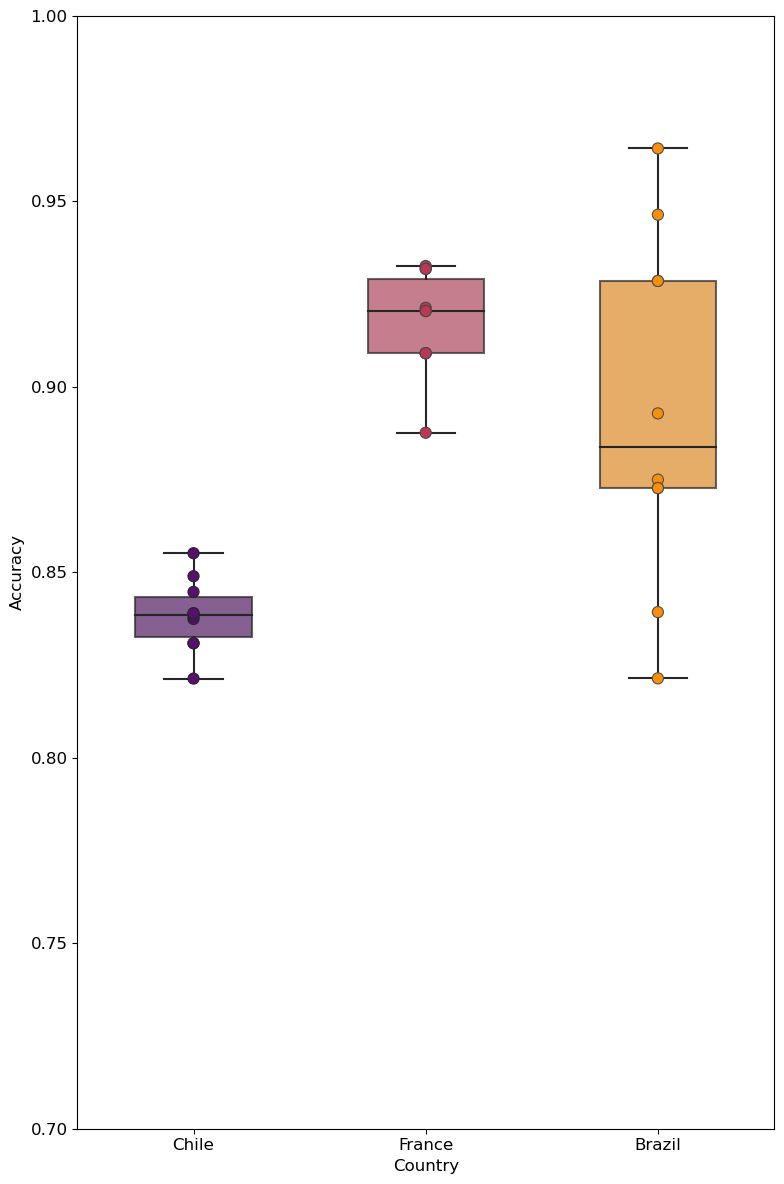

In [52]:
# --- Standardize fonts ---
mpl.rcParams['font.size']       = 12
mpl.rcParams['axes.labelsize']  = 14
mpl.rcParams['axes.titlesize']  = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12


files = {
    "Chile": 'data/cross_validation_scores_chile.csv',
    "France": 'data/cross_validation_scores_Francia.csv',  # Replace with actual file for France
    "Brazil": 'data/cross_validation_scores_Brasil.csv'   # Replace with actual file for Brazil
}

# File paths
files = {
    "Chile":  'data/cross_validation_scores_chile.csv',
    "France": 'data/cross_validation_scores_Francia.csv',
    "Brazil": 'data/cross_validation_scores_Brasil.csv'
}

dataframes = []
for country, file_path in files.items():
    df = pd.read_csv(file_path)
    df['Country'] = country
    dataframes.append(df)

combined_df = pd.concat(dataframes, ignore_index=True)

fig, ax = plt.subplots(1, 1, figsize=(8, 12))

sns.boxplot(
    x='Country', y='CV_Scores', data=combined_df, palette='inferno',
    showfliers=False, ax=ax, width=0.5, linewidth=1.5,
    boxprops={'alpha': 0.7}
)
sns.stripplot(
    x='Country', y='CV_Scores', data=combined_df, palette='inferno',
    dodge=False, size=8, jitter=0, linewidth=0.8, ax=ax
)

ax.set_ylim(0.7, 1)
ax.set_xlabel('Country')     # Will be 14 pt (axes.labelsize)
ax.set_ylabel('Accuracy')    # Same
# ax.set_title("Optional Title")

plt.tight_layout()
plt.savefig("Output/Boxplot D figure.svg", format='svg')
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13064\2652619353.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ext_iz['Political parties'] = 'Far-left [0,1]'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13064\2652619353.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ext_der['Political parties'] = 'Far-right [9,10]'
C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf val

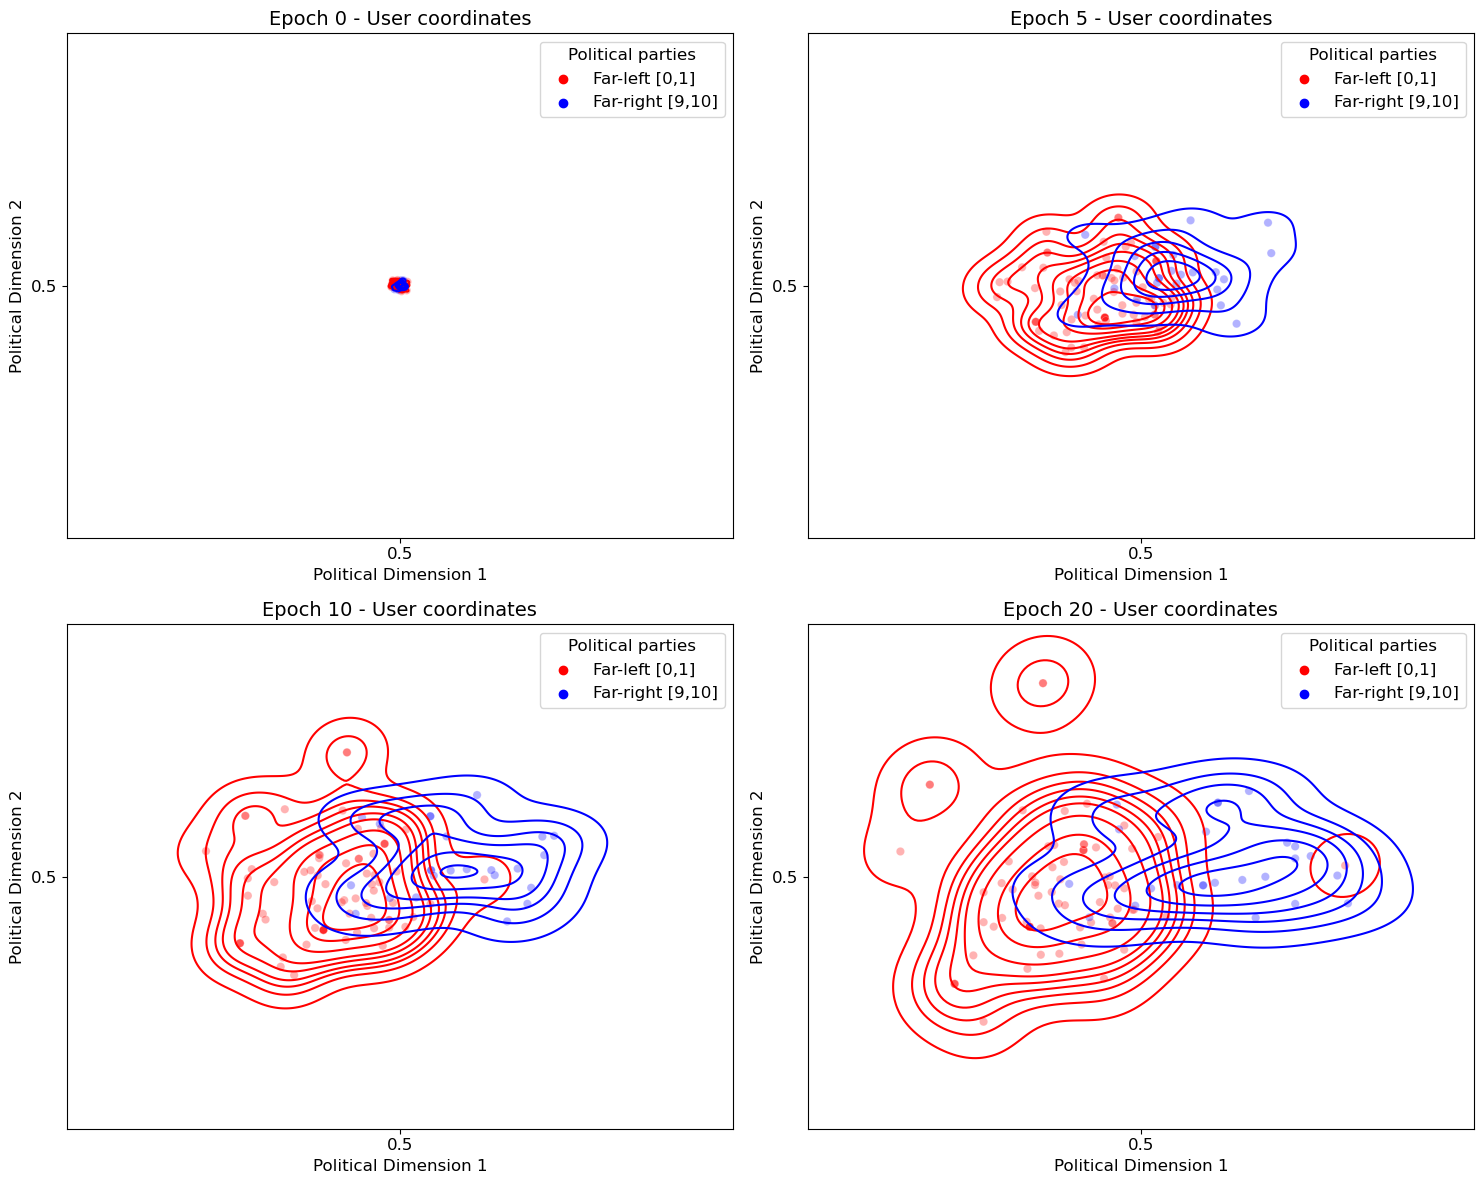

In [56]:
# --- Standardize fonts ---
mpl.rcParams['font.size']       = 12
mpl.rcParams['axes.labelsize']  = 14
mpl.rcParams['axes.titlesize']  = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12

# Function to preprocess coordinates
def preprocess_coords(coordsP_file, coordsU_file):
    coordsP = pd.read_csv(coordsP_file)
    coordsU = pd.read_csv(coordsU_file)
    # Filter extremes
    ext_iz = coordsU[(coordsU['politica'] >= 0) & (coordsU['politica'] <= 1)]
    ext_der = coordsU[(coordsU['politica'] >= 9) & (coordsU['politica'] <= 10)]
    ext_iz['Label'] = 'Far-left [0,1]'
    ext_der['Label'] = 'Far-right [9,10]'
    extremos = pd.concat([ext_iz, ext_der], axis=0)
    return coordsP, extremos

# Define the list of files
files_list = [
    ('Data/weights/coordsP_epoch_0_begin.csv',  'Data/weights/coordsU_epoch_0_begin.csv'),
    ('Data/weights/coordsP_epoch_5.csv',        'Data/weights/coordsU_epoch_5.csv'),
    ('Data/weights/coordsP_epoch_10.csv',       'Data/weights/coordsU_epoch_10.csv'),
    ('Data/weights/coordsP_epoch_20.csv',       'Data/weights/coordsU_epoch_20.csv')
]
epochs = [0, 5, 10, 20]

# --- Create a 2×2 square figure ---
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for idx, (coordsP_file, coordsU_file) in enumerate(files_list):
    coordsP, extremos = preprocess_coords(coordsP_file, coordsU_file)
    ax = axes[idx]
    sns.kdeplot(
        data=extremos, x='z2', y='z1', hue='Label',
        palette=["red", "blue"], ax=ax
    )
    sns.scatterplot(
        data=extremos, x='z2', y='z1', alpha=0.3, hue='Label',
        palette=["red", "blue"], ax=ax, legend=False
    )
    ax.set_xlabel('Political Dimension 1')
    ax.set_ylabel('Political Dimension 2')
    ax.set_title(f'Epoch {epochs[idx]} - User coordinates')
    ax.set_ylim(0.25, 0.75)
    ax.set_xlim(0.25, 0.75)
    ax.set_xticks([0.5])
    ax.set_yticks([0.5])
    ax.grid(False)

    # Add legend in the top-right corner with simplified labels
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))  # Ensure unique entries
    ax.legend(unique.values(), unique.keys(), loc='upper right')

plt.tight_layout()
plt.savefig('Output/Learning_B_figure.svg', format='svg')
plt.show()


# Version final

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13064\1759948342.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ext_iz['Label'] = 'Far-left [0,1]'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_13064\1759948342.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ext_der['Label'] = 'Far-right [9,10]'
C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operat

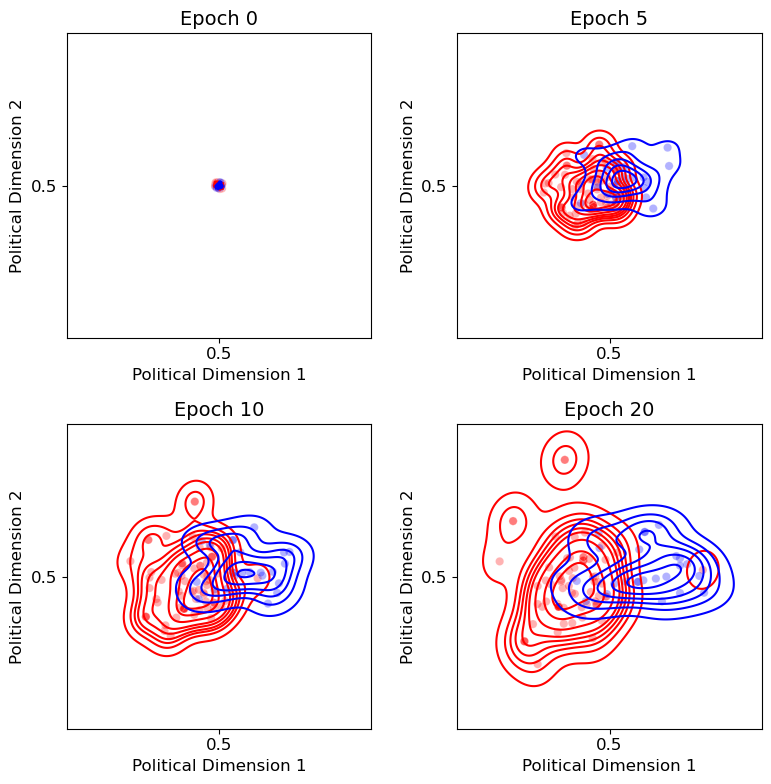

In [82]:
# --- Standardize fonts ---
mpl.rcParams['font.size']       = 12
mpl.rcParams['axes.labelsize']  = 14
mpl.rcParams['axes.titlesize']  = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12

# Function to preprocess coordinates
def preprocess_coords(coordsP_file, coordsU_file):
    coordsP = pd.read_csv(coordsP_file)
    coordsU = pd.read_csv(coordsU_file)
    # Filter extremes
    ext_iz = coordsU[(coordsU['politica'] >= 0) & (coordsU['politica'] <= 1)]
    ext_der = coordsU[(coordsU['politica'] >= 9) & (coordsU['politica'] <= 10)]
    ext_iz['Label'] = 'Far-left [0,1]'
    ext_der['Label'] = 'Far-right [9,10]'
    extremos = pd.concat([ext_iz, ext_der], axis=0)
    return coordsP, extremos

# Define the list of files
files_list = [
    ('Data/weights/coordsP_epoch_0_begin.csv',  'Data/weights/coordsU_epoch_0_begin.csv'),
    ('Data/weights/coordsP_epoch_5.csv',        'Data/weights/coordsU_epoch_5.csv'),
    ('Data/weights/coordsP_epoch_10.csv',       'Data/weights/coordsU_epoch_10.csv'),
    ('Data/weights/coordsP_epoch_20.csv',       'Data/weights/coordsU_epoch_20.csv')
]
epochs = [0, 5, 10, 20]

# --- Create a 2×2 square figure ---
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for idx, (coordsP_file, coordsU_file) in enumerate(files_list):
    coordsP, extremos = preprocess_coords(coordsP_file, coordsU_file)
    ax = axes[idx]
    sns.kdeplot(
        data=extremos, x='z2', y='z1', hue='Label',
        palette=["red", "blue"], ax=ax, legend=False  # Suppress legend for kdeplot
    )
    sns.scatterplot(
        data=extremos, x='z2', y='z1', alpha=0.3, hue='Label',
        palette=["red", "blue"], ax=ax, legend=False  # Suppress legend for scatterplot
    )
    ax.set_xlabel('Political Dimension 1')
    ax.set_ylabel('Political Dimension 2')
    ax.set_title(f'Epoch {epochs[idx]}')
    ax.set_ylim(0.25, 0.75)
    ax.set_xlim(0.25, 0.75)
    ax.set_xticks([0.5])
    ax.set_yticks([0.5])
    ax.grid(False)
    ax.set_aspect('equal')  # Ensure square aspect ratio

plt.tight_layout()
plt.savefig('Output/Learning_B_figure.svg', format='svg')
plt.show()




C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert in

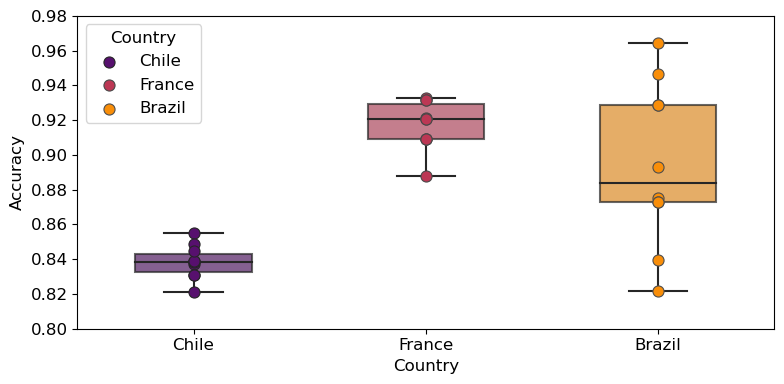

In [12]:
# --- Standardize fonts ---
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns

mpl.rcParams['font.size']       = 12
mpl.rcParams['axes.labelsize']  = 14
mpl.rcParams['axes.titlesize']  = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12

files = {
    "Chile":  'data/cross_validation_scores_chile.csv',
    "France": 'data/cross_validation_scores_Francia.csv',
    "Brazil": 'data/cross_validation_scores_Brasil.csv'
}

dataframes = []
for country, file_path in files.items():
    df = pd.read_csv(file_path)
    df['Country'] = country
    dataframes.append(df)

combined_df = pd.concat(dataframes, ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 4))

# Boxplot
sns.boxplot(
    x='Country', y='CV_Scores', data=combined_df,
    palette='inferno', showfliers=False, width=0.5, linewidth=1.5,
    boxprops={'alpha': 0.7}, ax=ax
)

# Stripplot with legend labels
palette = sns.color_palette("inferno", n_colors=len(files))
for i, (country, color) in enumerate(zip(files.keys(), palette)):
    subset = combined_df[combined_df['Country'] == country]
    sns.stripplot(
        x='Country', y='CV_Scores', data=subset,
        color=color, dodge=False, size=8, jitter=0,
        linewidth=0.8, ax=ax, label=country
    )

ax.set_ylim(0.8, 0.98)
ax.set_xlabel('Country')
ax.set_ylabel('Accuracy')
ax.legend(title='Country')  # Legend will now appear

plt.tight_layout()
plt.savefig("Output/5-Fig2-D-Boxplot-Figure.svg", format='svg')
plt.show()


C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


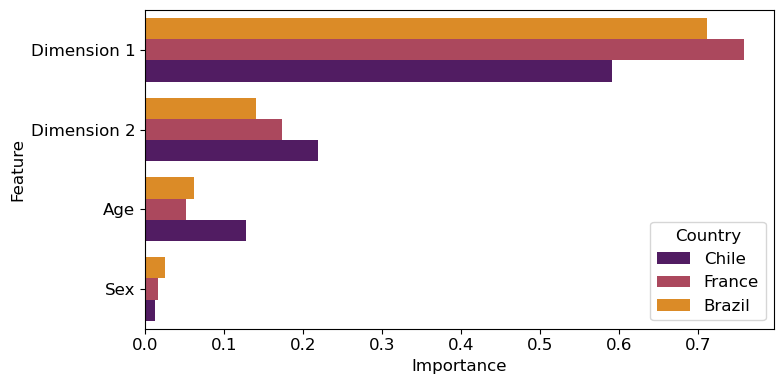

In [10]:
# --- Standardize fonts ---
mpl.rcParams['font.size']       = 12
mpl.rcParams['axes.labelsize']  = 14
mpl.rcParams['axes.titlesize']  = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12

data_combined_cleaned = pd.read_csv('Data/Cleaned_Feature_Importance_Data.csv')

data_combined_cleaned['Feature'] = pd.Categorical(
    data_combined_cleaned['Feature'],
    categories=['Sex', 'Age', 'Dimension 2', 'Dimension 1'],
    ordered=True
)
data_combined_cleaned['Country'] = pd.Categorical(
    data_combined_cleaned['Country'],
    categories=['Chile', 'France', 'Brazil'],
    ordered=True
)
data_combined_cleaned = data_combined_cleaned.sort_values(by=['Feature', 'Country'])

fig, ax = plt.subplots(figsize=(8, 4))  # <-- Square
sns.barplot(
    data=data_combined_cleaned,
    y='Feature', x='Importance',
    hue='Country', hue_order=['Chile', 'France', 'Brazil'],
    palette='inferno', ax=ax
)

ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
ax.legend(title='Country')

plt.gca().invert_yaxis()  # If you still want to reverse the order

plt.tight_layout()
plt.savefig("Output/6-Fig2-E-Feauture-Importance-Figure.svg", format='svg')
plt.show()

# Anexos

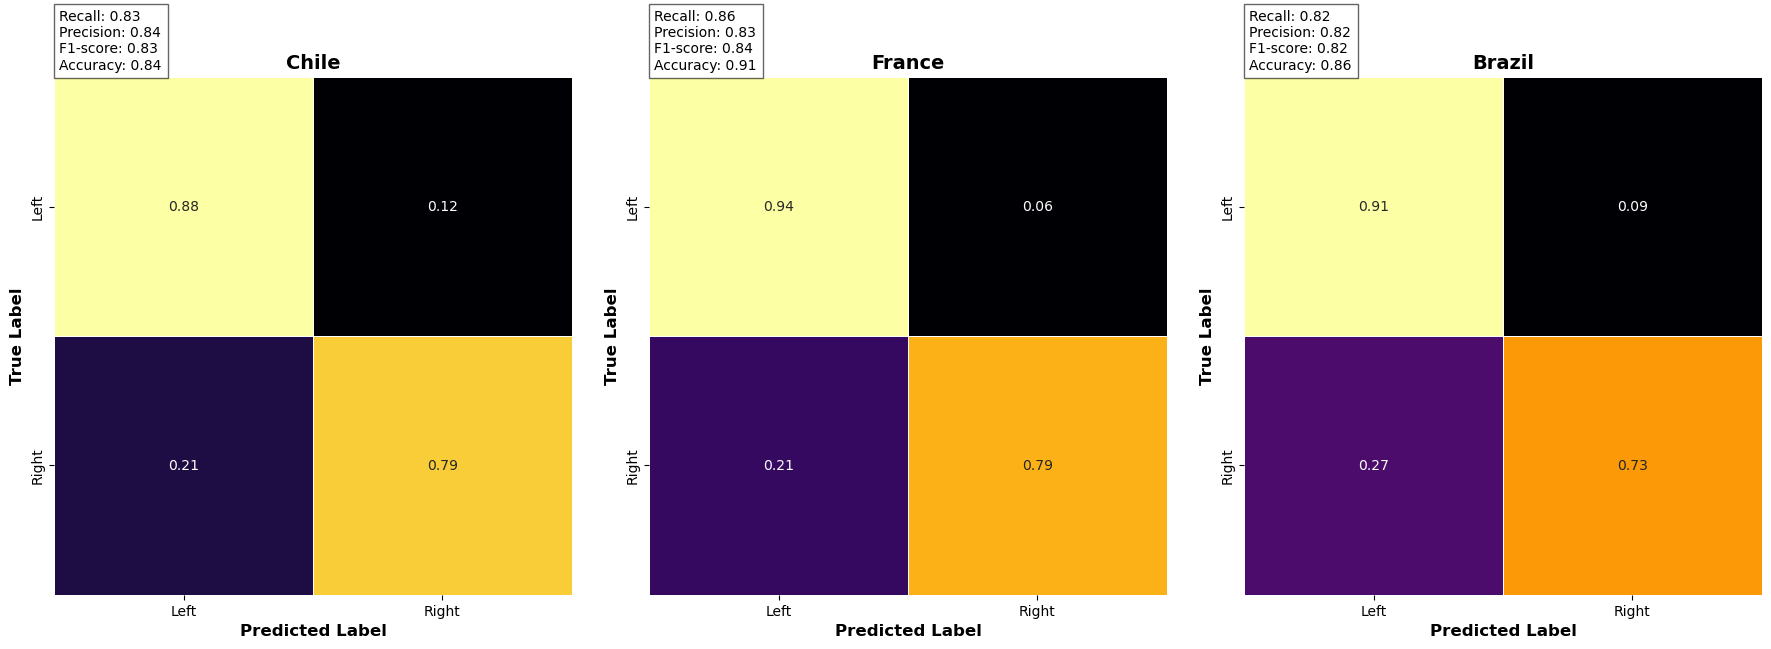

In [4]:
# Function to load data and extract metrics
def load_country_data(filepath):
    data = np.load(filepath, allow_pickle=True)
    matriz = data['matriz']
    classes = data['classes']
    metrics = dict(data['metrics'].item())
    return matriz, classes, metrics

# Function to plot a confusion matrix
def plot_confusion_matrix(ax, matriz, classes, metrics, country_name):
    # Extract metrics
    recall = metrics.get('recall', 0)
    precision = metrics.get('precision', 0)
    f1_score = metrics.get('f1_score', 0)
    acc = metrics.get('accuracy', 0)

    # Plot the confusion matrix
    sns.heatmap(
        matriz, 
        annot=True, 
        fmt='.2f', 
        linewidths=0.5, 
        square=True, 
        cmap='inferno', 
        xticklabels=classes, 
        yticklabels=classes, 
        cbar=False, 
        annot_kws={'size': 10}, 
        ax=ax
    )

    # Axis labels
    ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_title(f'{country_name}', fontsize=14, fontweight='bold')

    # Display metrics inside the subplot
    metrics_text = (
        f'Recall: {recall:.2f}\n'
        f'Precision: {precision:.2f}\n'
        f'F1-score: {f1_score:.2f}\n'
        f'Accuracy: {acc:.2f}'
    )
    ax.text(
        0.01, 1.07, 
        metrics_text, 
        va='center', 
        transform=ax.transAxes, 
        fontsize=10, 
        bbox=dict(facecolor='white', alpha=0.6)
    )

# Filepaths for the countries
filepaths = {
    'Chile': "Data/confusion_matrix_data_Chile.npz",
    'France': "Data/confusion_matrix_data_Francia.npz",
    'Brazil': "Data/confusion_matrix_data_Brasil.npz"
}

# Initialize the figure and axes
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

# Loop through countries and plot each confusion matrix
for ax, (country, filepath) in zip(axes, filepaths.items()):
    matriz, classes, metrics = load_country_data(filepath)
    plot_confusion_matrix(ax, matriz, classes, metrics, country)

# Adjust layout
plt.tight_layout()
plt.savefig("Output/confusion_matrices.svg", format='svg', bbox_inches='tight')
plt.show()


C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert in

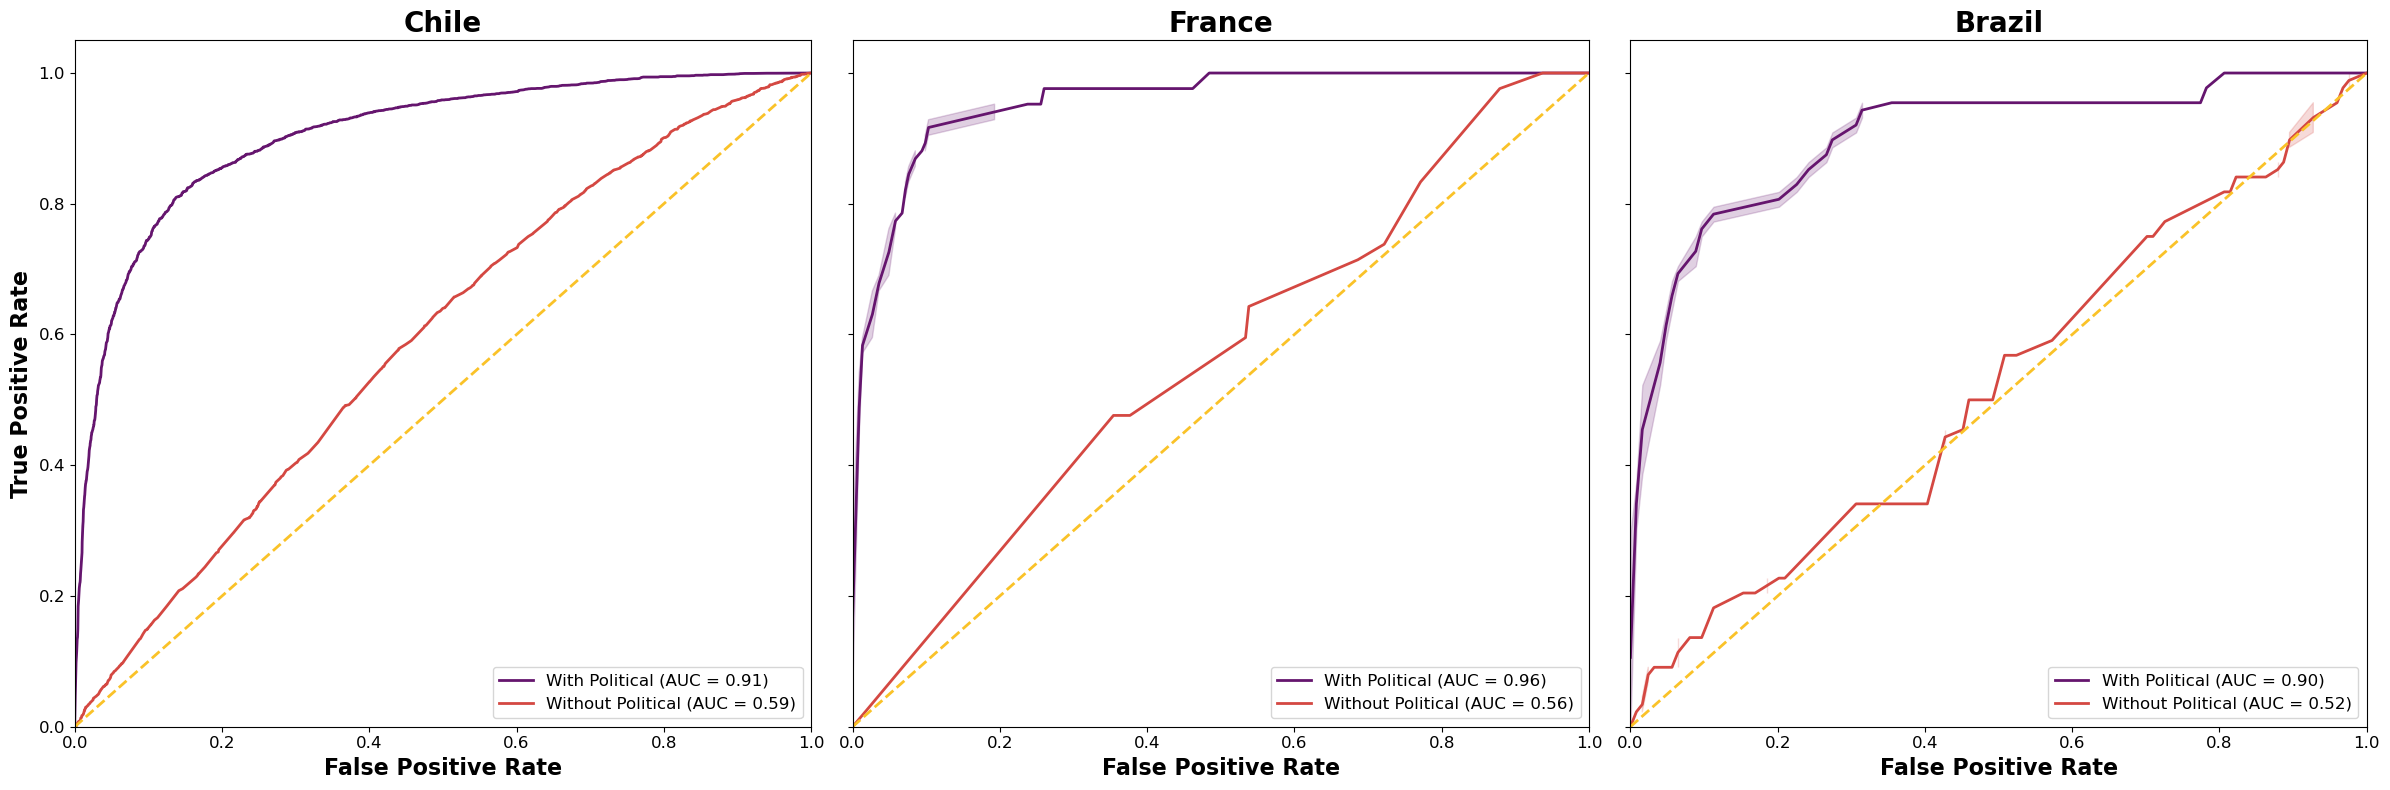

In [6]:
# Define file paths for each country
countries = ['Chile', 'France', 'Brazil']
data_files = {
    country: {
        'with_political': f'Data/roc_with_political_{country.lower()}.csv',
        'without_political': f'Data/roc_without_political_{country.lower()}.csv',
        'auc': f'Data/roc_auc_values_{country.lower()}.csv'
    }
    for country in countries
}

# Initialize plot
fig, axs = plt.subplots(1, 3, figsize=(24, 8), sharey=True)

# Plot ROC curves for each country
for i, country in enumerate(countries):
    try:
        # Load data
        roc_data = pd.read_csv(data_files[country]['with_political'])
        roc_socio_data = pd.read_csv(data_files[country]['without_political'])
        auc_data = pd.read_csv(data_files[country]['auc'])

        # Extract AUC values
        roc_auc = auc_data.loc[auc_data['Model'] == 'With Political Dimensions', 'AUC'].values[0]
        roc_auc_socio = auc_data.loc[auc_data['Model'] == 'Without Political Dimensions', 'AUC'].values[0]

        # Plot data
        sns.lineplot(
            ax=axs[i],
            x=roc_data['FPR'], y=roc_data['TPR'],
            color=sns.color_palette('inferno')[1], lw=2,
            label=f'With Political (AUC = {roc_auc:.2f})'
        )
        sns.lineplot(
            ax=axs[i],
            x=roc_socio_data['FPR'], y=roc_socio_data['TPR'],
            color=sns.color_palette('inferno')[3], lw=2,
            label=f'Without Political (AUC = {roc_auc_socio:.2f})'
        )
        axs[i].plot([0, 1], [0, 1], color=sns.color_palette('inferno')[5], lw=2, linestyle='--')

        # Customize subplot
        axs[i].set_xlim([0.0, 1.0])
        axs[i].set_ylim([0.0, 1.05])
        axs[i].set_title(f'{country}', fontsize=20, fontweight='bold')
        axs[i].set_xlabel('False Positive Rate', fontsize=16, fontweight='bold')
        axs[i].set_ylabel('True Positive Rate', fontsize=16, fontweight='bold' if i == 0 else None)
        axs[i].legend(loc='lower right', fontsize=12)
        axs[i].tick_params(axis='both', labelsize=12)
    except FileNotFoundError as e:
        axs[i].text(0.5, 0.5, 'Data Missing', fontsize=16, ha='center', va='center')
        axs[i].set_title(f'{country} (Data Missing)', fontsize=20, fontweight='bold')

# Adjust layout
plt.tight_layout()
plt.savefig("Output/7-Fig2-F-ROC-AUC.svg", format='svg', bbox_inches='tight')
plt.show()

In [18]:
data_combined_acc_loss = pd.read_csv('Data/DataTraining_and_Validation_Accuracy_Loss.csv')
data_combined_acc_loss

,Epoch,Country,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,1,Chile,0.6612,0.6653,0.6118,0.6092
1,2,Chile,0.6817,0.6772,0.5892,0.5965
2,3,Chile,0.6957,0.6843,0.5735,0.5893
3,4,Chile,0.7034,0.6862,0.5655,0.5866
4,5,Chile,0.7083,0.6887,0.5606,0.5841
5,6,Chile,0.7108,0.6885,0.5576,0.5842
6,7,Chile,0.7123,0.6888,0.5560,0.5863
7,8,Chile,0.7127,0.6886,0.5553,0.5848
8,9,Chile,0.7127,0.6880,0.5552,0.5868
9,10,Chile,0.7125,0.6869,0.5554,0.5880


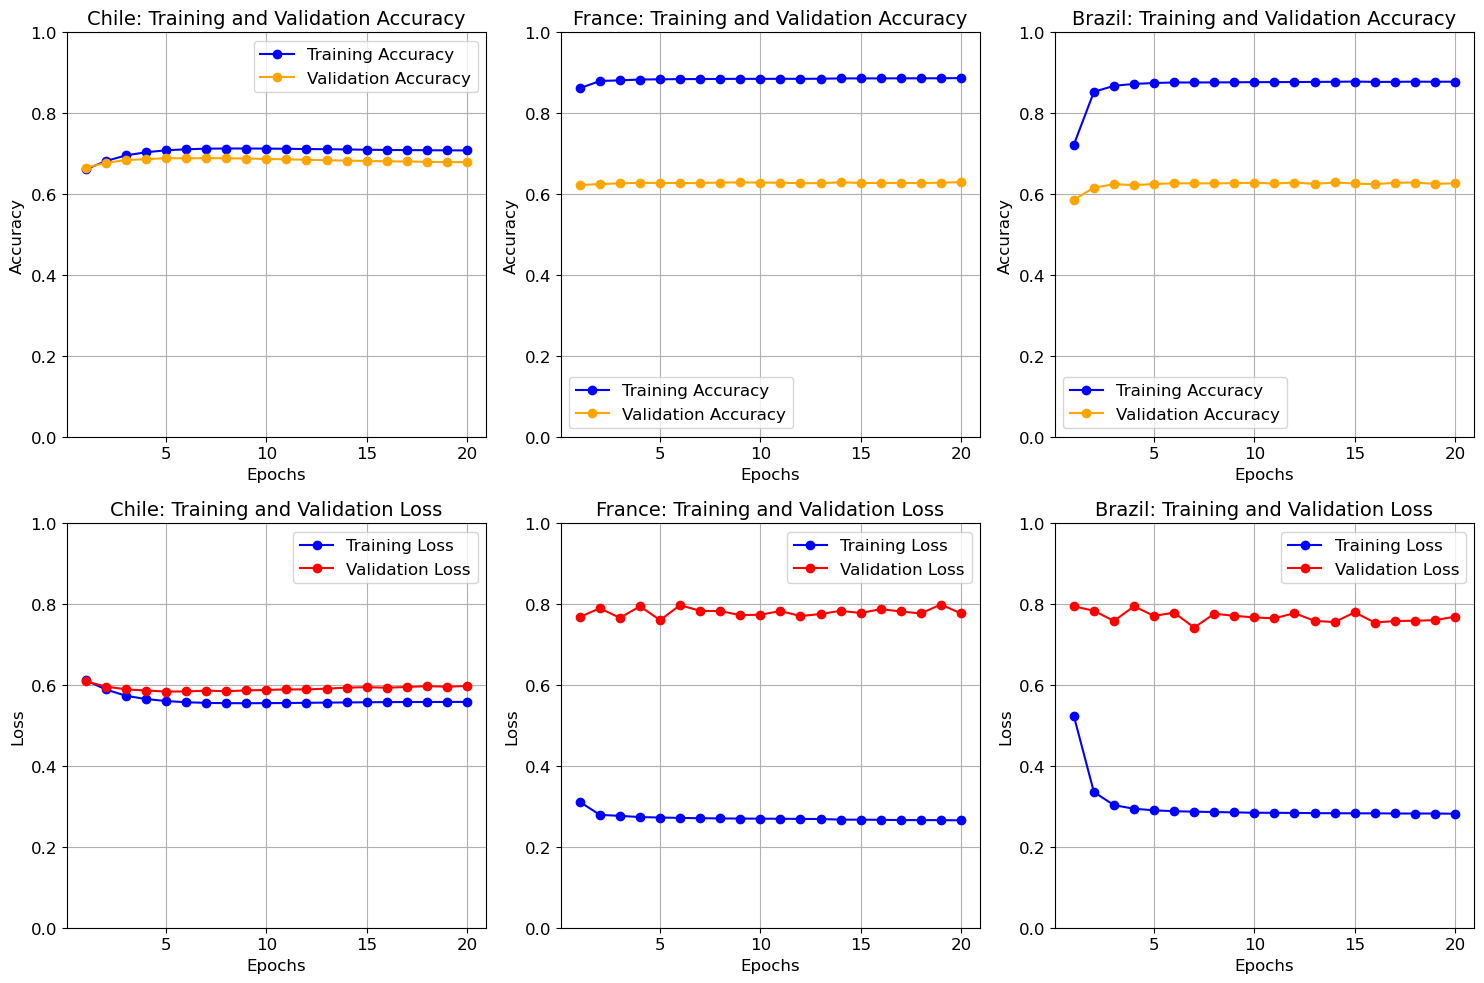

In [21]:
# Re-import necessary libraries after execution state reset
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Standardize fonts
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12

# Reload the dataset
file_path = "Data/DataTraining_and_Validation_Accuracy_Loss.csv"
data = pd.read_csv(file_path)

# Extract unique countries and epochs
countries = data["Country"].unique()
epochs = data["Epoch"].unique()

# Prepare data dictionaries (correct mapping)
training_accuracy = {country: data[data["Country"] == country]["Training Accuracy"].values for country in countries}
validation_accuracy = {country: data[data["Country"] == country]["Validation Accuracy"].values for country in countries}
training_loss = {country: data[data["Country"] == country]["Training Loss"].values for country in countries}
validation_loss = {country: data[data["Country"] == country]["Validation Loss"].values for country in countries}

# Create a 2x3 grid layout for better visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Data for plotting (Accuracy & Loss with correct colors)
plot_data = [
    ("Accuracy", training_accuracy, validation_accuracy, "blue", "orange"),
    ("Loss", training_loss, validation_loss, "blue", "red"),
]

# Iterate through the plots (2x3 grid)
for i, (metric_name, train_dict, val_dict, train_color, val_color) in enumerate(plot_data):
    for j, country in enumerate(countries):
        ax = axes[i * 3 + j]
        ax.plot(epochs, train_dict[country], 'o-', label=f'Training {metric_name}', color=train_color)
        ax.plot(epochs, val_dict[country], 'o-', label=f'Validation {metric_name}', color=val_color)
        ax.set_xlabel('Epochs')
        ax.set_ylabel(metric_name)
        ax.set_title(f'{country}: Training and Validation {metric_name}')
        ax.grid(True)
        ax.legend()
        
        # Fix Y-axis range to 0-1 for all plots
        ax.set_ylim(0, 1)


# Adjust layout
plt.tight_layout()
plt.savefig("Output/SM-Training and Validation.svg", format='svg', bbox_inches='tight')
plt.show()



### Accuracy by votes

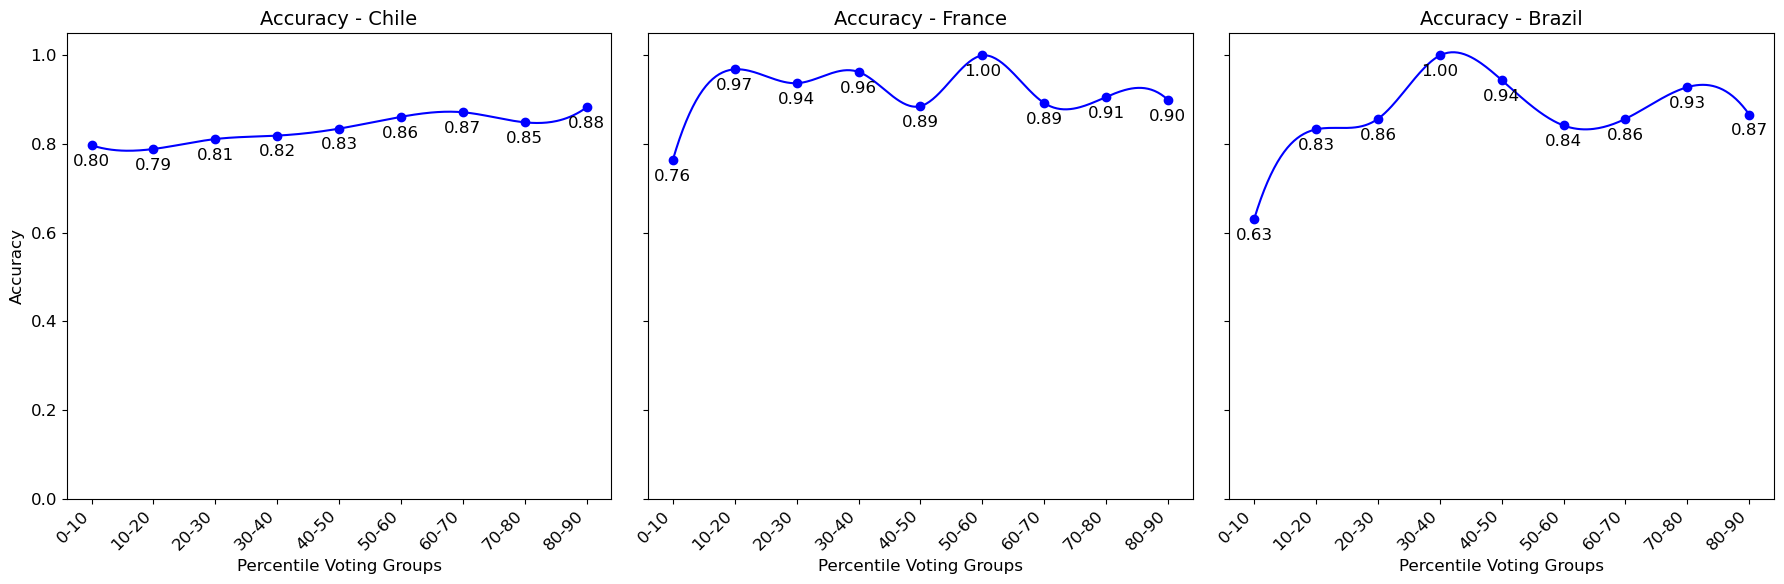

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import numpy as np
import os

# Standardize fonts
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12

# Define file paths
file_paths = {
    "Chile": "Data/Groups_Accuracy_Chile.csv",
    "France": "Data/Groups_Accuracy_France.csv",
    "Brazil": "Data/Groups_Accuracy_brazil.csv"

}
# Define figure and axes for a 1x3 layout
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Iterate over each file and corresponding subplot
for idx, (country, file_path) in enumerate(file_paths.items()):
    # Load the data
    df = pd.read_csv(file_path)

    # Ensure no missing values
    if df.isnull().values.any():
        raise ValueError(f"The CSV {file_path} contains missing values, check the data integrity.")

    # Generate the X-axis
    x_values = np.arange(len(df['Accuracy']))

    # Smooth the curve using interpolation if there are enough data points
    if len(df['Accuracy']) > 3:
        xnew = np.linspace(0, len(df['Accuracy']) - 1, 300)
        spl = make_interp_spline(x_values, df['Accuracy'], k=3)
        y_smooth = spl(xnew)
        axes[idx].plot(xnew, y_smooth, label='Accuracy', color='blue')

    # Add scatter points
    axes[idx].scatter(x_values, df['Accuracy'], color='blue', marker='o')

    # Annotate each point with its accuracy value, slightly lowering the text to avoid overlap
    for i, txt in enumerate(df['Accuracy']):
        axes[idx].annotate(f'{txt:.2f}', (i, txt), textcoords="offset points", xytext=(0, -15), ha='center')

    # Set X-axis labels as percentiles instead of group size intervals
    percentiles = [f"{i*10}-{(i+1)*10}" for i in range(len(df['Votaciones']))]
    axes[idx].set_xticks(x_values)
    axes[idx].set_xticklabels(percentiles, rotation=45, ha="right")
    axes[idx].set_xlabel("Percentile Voting Groups")

    # Set title
    axes[idx].set_title(f"Accuracy - {country}")

    # Set Y-axis limits from 0 to 1.2 to avoid overlapping text with the title
    axes[idx].set_ylim(0, 1.05)

# Set common Y-label
axes[0].set_ylabel("Accuracy")

# Adjust layout
# Adjust layout
plt.tight_layout()
plt.savefig("Output/SM-Percentile Voting Groups.svg", format='svg', bbox_inches='tight')
plt.show()
